<a href="https://colab.research.google.com/github/Ariqq16/PCVK_Ganjil_2026/blob/main/P6/Filter_Library_dan_Modern.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Percobaan 1


In [ ]:
import torch
import torch.nn as nn

def show_side_by_side(images, titles, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i+1)
        if len(img.shape) == 2:
            plt.imshow(img, cmap="gray")
        else:
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

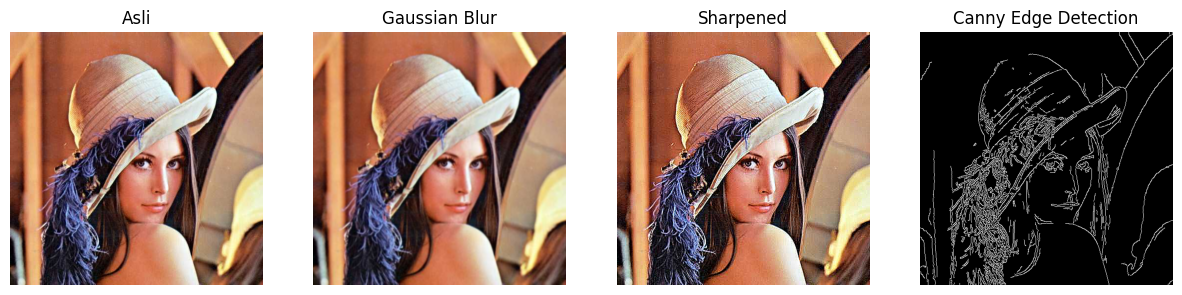

In [ ]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

kernel_sharpen = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]])

BASE_PATH = ''
img_lena = cv.imread(BASE_PATH + '/content/drive/MyDrive/PCVK_2026/lena.jpg')

blur_p1 = cv.GaussianBlur(img_lena, (7, 7), 1)
edges_p1 = cv.Canny(cv.cvtColor(img_lena, cv.COLOR_BGR2GRAY), 100, 200)
sharpened_p1 = cv.filter2D(img_lena, -1, kernel_sharpen)
show_side_by_side([img_lena, blur_p1, sharpened_p1, edges_p1],
                   ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])

Percobaan 2


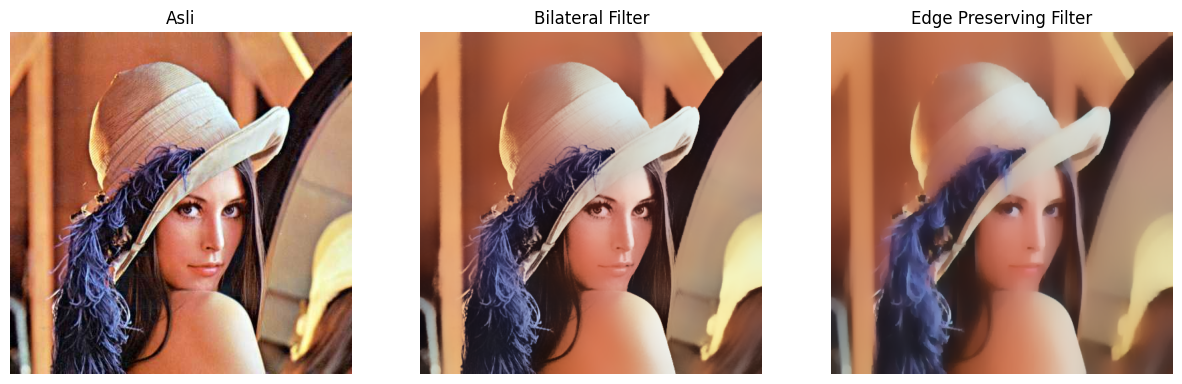

In [ ]:
bilateral_p2 = cv.bilateralFilter(img_lena, 50, 100, 100)
edge_preserve_p2 = cv.edgePreservingFilter(img_lena, flags=1, sigma_s=100, sigma_r=0.9)
show_side_by_side([img_lena, bilateral_p2, edge_preserve_p2],
                   ["Asli", "Bilateral Filter", "Edge Preserving Filter"])

Pecobaan 3

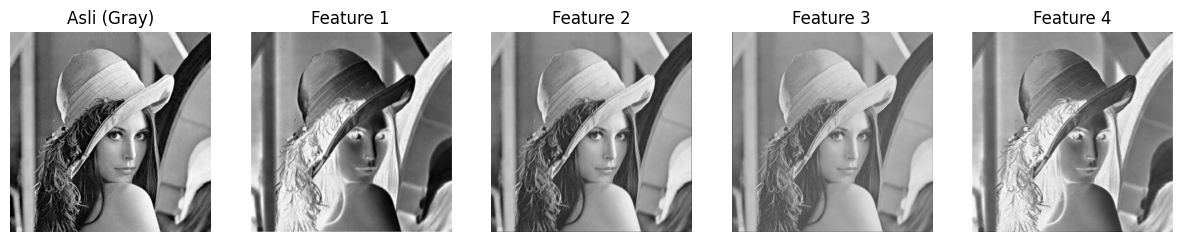

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)
    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()
img_gray_lena = cv.cvtColor(img_lena, cv.COLOR_BGR2GRAY)
img_tensor = torch.tensor(img_gray_lena, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

with torch.no_grad():
    features = model(img_tensor)

feature_maps = [features[0, i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray_lena] + feature_maps,
                   ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))])

Pecobaan 4

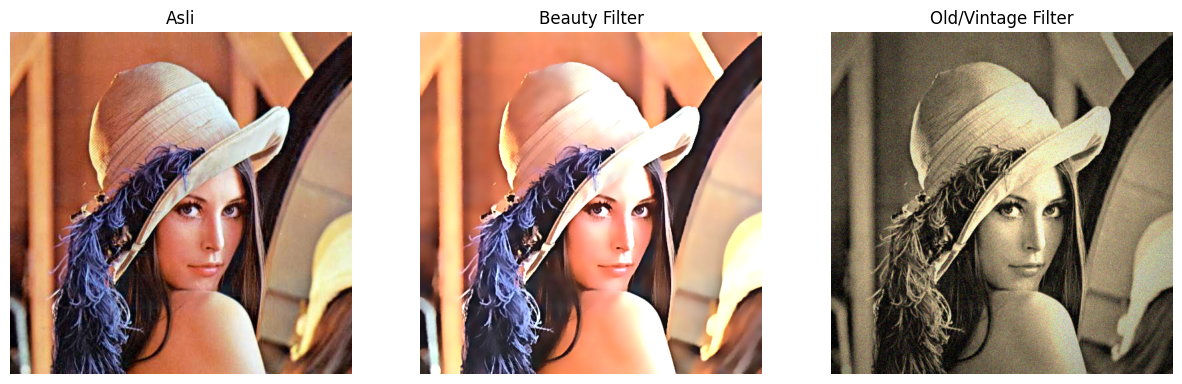

In [ ]:
smooth_b = cv.bilateralFilter(img_lena, d=15, sigmaColor=75, sigmaSpace=75)
gaussian_b = cv.GaussianBlur(smooth_b, (0, 0), 3)
sharpened_b = cv.addWeighted(smooth_b, 1.5, gaussian_b, -0.5, 0)
beauty = cv.convertScaleAbs(sharpened_b, alpha=1.2, beta=15)

sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img_lena, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

rows, cols = img_lena.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, rows*0.6)
mask_vignette = (kernel_y @ kernel_x.T) / (kernel_y @ kernel_x.T).max()

vignette = np.copy(sepia)
for i in range(3):
    vignette[:, :, i] = vignette[:, :, i] * mask_vignette

noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

show_side_by_side([img_lena, beauty, old_img], ["Asli", "Beauty Filter", "Old/Vintage Filter"])

Percobaan 5

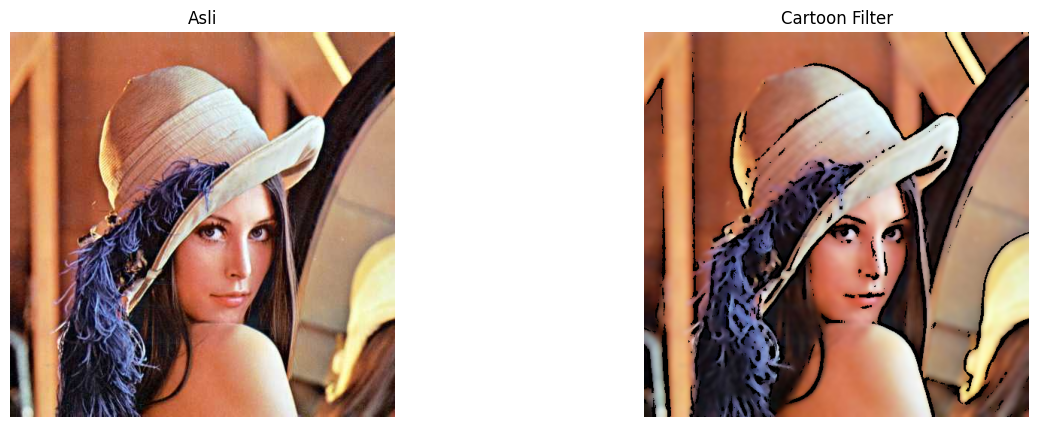

In [ ]:
gray_c = cv.cvtColor(img_lena, cv.COLOR_BGR2GRAY)
gray_blur_c = cv.medianBlur(gray_c, 7)
edges_c = cv.adaptiveThreshold(gray_blur_c, 255, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, 9, 9)
color_c = cv.bilateralFilter(img_lena, d=9, sigmaColor=200, sigmaSpace=200)
cartoon = cv.bitwise_and(color_c, color_c, mask=edges_c)

show_side_by_side([img_lena, cartoon], ["Asli", "Cartoon Filter"])

Percobaan 6

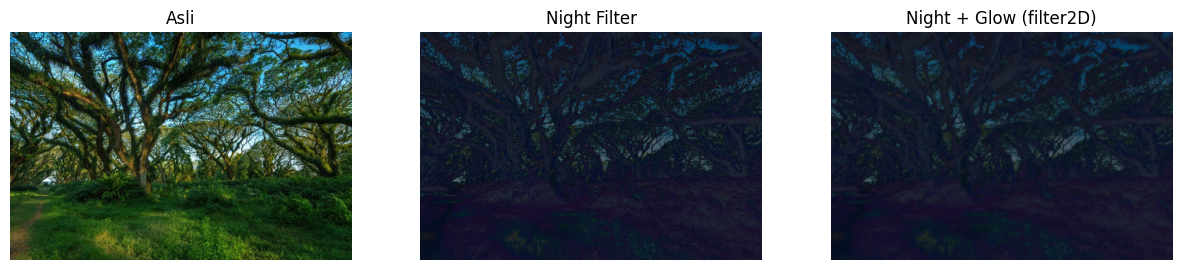

In [15]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
img_djawatan = cv.imread(BASE_PATH + '/content/drive/MyDrive/PCVK_2026/djawatan.jpg')
if img_djawatan is None:
    img_djawatan = img_lena.copy()

# Night Filter
night = cv.convertScaleAbs(img_djawatan, alpha=0.6, beta=-40)
blue_tint = np.full_like(night, (100, 50, 0)) # BGR
night_tint = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)
kernel_glow = np.ones((15, 15), np.float32) / 225
glow = cv.filter2D(night_tint, -1, kernel_glow)
night_glow = cv.addWeighted(night_tint, 0.7, glow, 0.3, 0)

show_side_by_side([img_djawatan, night_tint, night_glow], ["Asli", "Night Filter", "Night + Glow (filter2D)"])


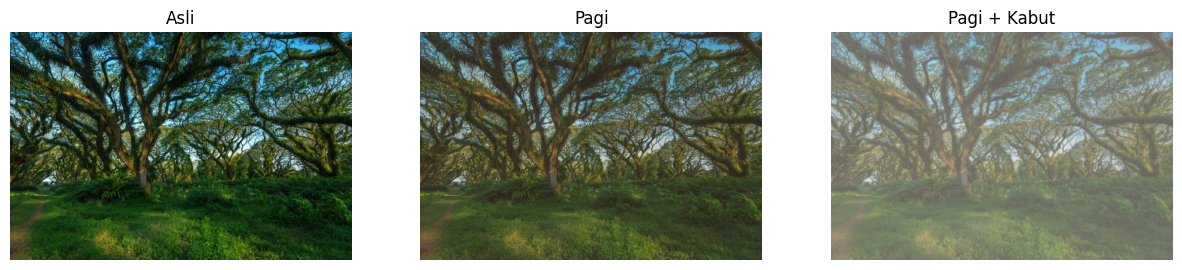

In [16]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
img_djawatan = cv.imread(BASE_PATH + '/content/drive/MyDrive/PCVK_2026/djawatan.jpg')
if img_djawatan is None:
    img_djawatan = img_lena.copy()

# Pagi + Kabut Filter
soft_pagi = cv.convertScaleAbs(img_djawatan, alpha=0.9, beta=20)
warm_tint = np.full_like(soft_pagi, (40, 70, 120)) # BGR
pagi = cv.addWeighted(soft_pagi, 0.8, warm_tint, 0.2, 0)

k_g = cv.getGaussianKernel(3, 3)
kernel_fog = k_g @ k_g.T
kabut = cv.filter2D(pagi, -1, kernel_fog)
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img_djawatan, pagi, kabut], ["Asli", "Pagi", "Pagi + Kabut"])